In [172]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from routes_preprocessing import *





In [173]:
# Last file of 2024 used for testing and analytics
filename = "../datasets/MBTA-Bus-Arrival-Departure-Times_2024-12.csv"

In [174]:
df = pd.read_csv(filename, low_memory=False)

In [175]:
avg_positive_delay_per_route = preprocess_routes(df)


/Users/anthonysevilla/Documents/CS/CS 506/CS 506 Project/506-data-analysis/bus-delay-time-analysis/routes_preprocessing.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  routes_df['time_difference'] = pd.to_datetime(routes_df['actual']) - pd.to_datetime(routes_df['scheduled'])
/Users/anthonysevilla/Documents/CS/CS 506/CS 506 Project/506-data-analysis/bus-delay-time-analysis/routes_preprocessing.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  routes_df['delay_seconds'] = routes_df['time_difference'].d

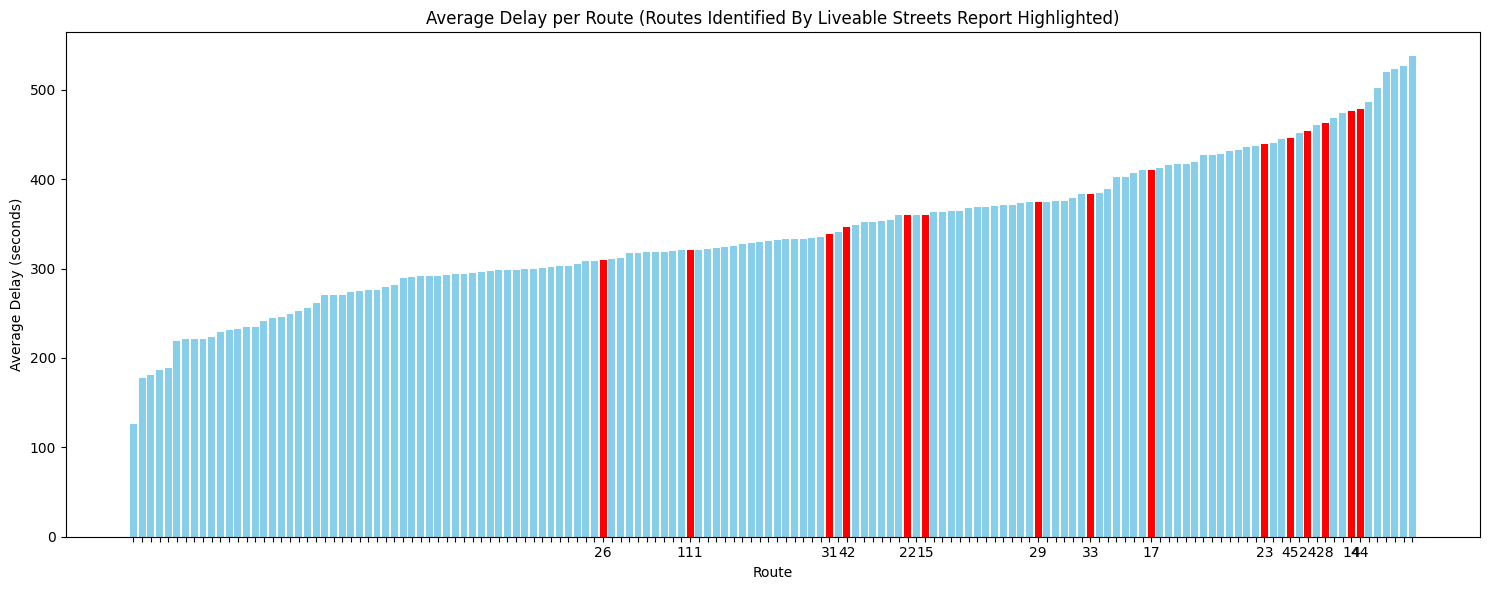

In [177]:
target_routes = {"22", "29", "15", "45", "28", "44", "42", "17", "23", "31", "26", "111", "24", "33", "14"}


avg_positive_delay_per_route = avg_positive_delay_per_route.sort_values(by='delay_seconds', ascending=True)



colors = ['red' if route in target_routes else 'skyblue' for route in avg_positive_delay_per_route['route_id']]

tick_labels = [route if route in target_routes else '' for route in avg_positive_delay_per_route['route_id']]


plt.figure(figsize=(15, 6))
plt.bar(avg_positive_delay_per_route['route_id'], avg_positive_delay_per_route['delay_seconds'], color=colors)
plt.xlabel('Route')
plt.ylabel('Average Delay (seconds)')
plt.title('Average Delay per Route (Routes Identified By Liveable Streets Report Highlighted)')
plt.xticks(range(len(avg_positive_delay_per_route['route_id'])), tick_labels)
plt.tight_layout()
plt.show()

